In [2]:
import torch
import numpy as np
import torch.nn as nn
from torch.nn import functional as F
print(torch.__version__)
print(np.__version__)


2.9.0.dev20250909+cu128
2.2.6


# 分块实现
### Embedding

In [3]:
seq_len = 4
tgt_len = 6
vocab_size = 100
batch_size = 2
d_model = 512

x = torch.randint(0, vocab_size, (batch_size, seq_len))

print("源序列形状:", x.shape)



源序列形状: torch.Size([2, 4])


In [4]:
embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=d_model)
x_embedded = embedding(x)
print(f"Embedding后形状: {x_embedded.shape}")

Embedding后形状: torch.Size([2, 4, 512])


### 位置编码
对于位置为 $pos$（从 0 开始），维度索引为 $i$（从 0 到 511）的数值：
- 偶数维度使用正弦：
$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
- 奇数维度使用余弦：
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

In [5]:
import math

# 位置编码
# 目的：对每个position的词的embedding维度进行位置编码，生成一个[position,emb_dim]的矩阵
# # 一行是一个position的词，一行中的每个元素根据其在dim中的位置使用sin或cos编码 
# 偶数维度使用正弦
# # PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
# 奇数维度使用余弦
# # PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

max_len = 5000

pe = torch.zeros(max_len, d_model)
position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1) # 将position扩充成列
print(position.shape)
# 分母部分：1/10000^(2i/d_model)，为了计算稳定，通常转换成指数形式，作用于一行中的每个元素
# 1/10000^(2i/d_model) = exp[(2i/d_model)*(-ln 10000)]
# torch.arange(0, d_model, 2)生成一个[0, 2, 4, ...]序列
div_term = torch.exp(torch.arange(0, d_model, 2).float() * -math.log(10000.0) / d_model)
print(div_term.shape)

# 偶数部分
pe[:, 0::2] = torch.sin(position * div_term)
pe[:, 1::2] = torch.cos(position * div_term)

pe = pe.unsqueeze(0)    # 添加batch维度

print("\n3. 生成的位置编码矩阵形状:", pe.shape)

torch.Size([5000, 1])
torch.Size([256])

3. 生成的位置编码矩阵形状: torch.Size([1, 5000, 512])


In [6]:
# pe.shape(1)是最长序列长度，只需要截取出x_embedded的序列长即可
x_final = x_embedded + pe[:, :x_embedded.size(1), :]

### QKV映射

In [7]:
d_k = 64
d_v = 64

W_q = nn.Linear(d_model, d_k)
W_k = nn.Linear(d_model, d_k)
W_v = nn.Linear(d_model, d_v)

Q = W_q(x_final)
K = W_q(x_final)
V = W_v(x_final)

print(f"Q shape: {Q.shape}")
print(f"K shape: {K.shape}")

Q shape: torch.Size([2, 4, 64])
K shape: torch.Size([2, 4, 64])


### 计算注意力
$$attention = softmax(QK^T/\sqrt{d_{model}})$$

In [8]:
# 计算QK^T
# 将K的最后两个维度转置以进行QK^T矩阵乘法
K_transposed = K.transpose(-2, -1)
print(f"K转置后形状：{K_transposed.shape}")

scores = torch.matmul(Q, K_transposed)
print("\n2. 打分矩阵 scores 的形状:", scores.shape)

K转置后形状：torch.Size([2, 64, 4])

2. 打分矩阵 scores 的形状: torch.Size([2, 4, 4])


In [9]:
# 缩放
scaled_scores = scores / math.sqrt(d_k)

# 归一化
attn_weights = F.softmax(scaled_scores, dim=-1)

print("\n3. 注意力权重 attn_weights 的形状:", attn_weights.shape) # 预期: [2, 4, 4]
print("   第一个batch，第一句话，第一个词对所有词的注意力分配:\n", attn_weights[0, 0, :])


3. 注意力权重 attn_weights 的形状: torch.Size([2, 4, 4])
   第一个batch，第一句话，第一个词对所有词的注意力分配:
 tensor([0.9193, 0.0289, 0.0199, 0.0319], grad_fn=<SelectBackward0>)


In [10]:
context_vector = torch.matmul(attn_weights, V)

print("\n4. 最终输出的上下文向量形状:", context_vector.shape) # 预期: [2, 4, 64]


4. 最终输出的上下文向量形状: torch.Size([2, 4, 64])


### 多头注意力

In [11]:
# 多头注意力
num_heads = 8

batch_size = 2
seq_len = 4
d_model = 512
d_k = d_model // num_heads

torch.manual_seed(42)
# 模拟一个已经加入了位置编码的输入
x_final = torch.randn(batch_size, seq_len, d_model)

# 1. 定义三个“大”线性变换矩阵
# 输入 512 维，输出依然是 512 维，这 512 维里其实暗含了 8 个 64 维的头
W_Q = nn.Linear(d_model, d_model)
W_K = nn.Linear(d_model, d_model)
W_V = nn.Linear(d_model, d_model)

# 2. 一次性算出包含了所有头的 Q, K, V
Q_big = W_Q(x_final)
K_big = W_K(x_final)
V_big = W_V(x_final)

print("1. 大 Q 矩阵的形状:", Q_big.shape)

1. 大 Q 矩阵的形状: torch.Size([2, 4, 512])


In [12]:
# 拆分8个头，将Q、K、V从[batch_size, seq_len, d_model]拆成[batch_size, seq_len, num_heads, d_model]
Q_split = Q_big.view(batch_size, seq_len, num_heads, d_k)
K_split = K_big.view(batch_size, seq_len, num_heads, d_k)
V_split = V_big.view(batch_size, seq_len, num_heads, d_k)

# 因为计算QK^T的时候要用[seq_len,d_k] × [d_k,seq_len]，但是现在后两维是[num_heads,d_model]所以要交换维度seq_len和num_heads
Q = Q_split.transpose(1, 2)
K = K_split.transpose(1, 2)
V = V_split.transpose(1, 2)

print("\n2. 变形换位后 Q 的形状:", Q.shape) # 预期: [2, 8, 4, 64]


2. 变形换位后 Q 的形状: torch.Size([2, 8, 4, 64])


In [13]:
K_transposed = K.transpose(-2, -1)
scores = torch.matmul(Q, K_transposed)

scaled_scores = scores / math.sqrt(d_k)

attn_weights = F.softmax(scaled_scores, dim=-1)

context_multi = torch.matmul(attn_weights, V)

print("\n3. 多头并行计算后的上下文向量形状:", context_multi.shape) # 预期: [2, 8, 4, 64]


3. 多头并行计算后的上下文向量形状: torch.Size([2, 8, 4, 64])


In [14]:
context_multi_transposed = context_multi.transpose(1, 2)

# 避坑提示：经过 transpose 操作后，张量在内存中的存储不再是连续的了。
# 如果直接用 view() 会报错，必须先调用 contiguous() 在内存中重新排好序！
context_contiguous = context_multi_transposed.contiguous()

# 2. 拼接所有的头: [2, 4, 8, 64] -> [2, 4, 512]
context_vector_concat = context_contiguous.view(batch_size, seq_len, d_model)
print("\n4. 拼接后的张量形状:", context_vector_concat.shape) # 预期: [2, 4, 512]

W_O = nn.Linear(d_model, d_model)
multi_head_output = W_O(context_vector_concat)

print("   最终的多头注意力输出形状:", multi_head_output.shape) # 预期: [2, 4, 512]


4. 拼接后的张量形状: torch.Size([2, 4, 512])
   最终的多头注意力输出形状: torch.Size([2, 4, 512])


### 残差连接

In [15]:
added_output = x_final + multi_head_output
print("1. 残差相加后的形状:", added_output.shape) # 预期: [2, 4, 512]

1. 残差相加后的形状: torch.Size([2, 4, 512])


### Layer Norm
在处理文本序列时，我们不用批归一化 (BatchNorm)，而是用 层归一化 (LayerNorm)。
为什么？因为每句话的长度是不一样的，BatchNorm 会跨越不同的句子去求均值，这在 NLP 里会引发灾难。LayerNorm 则是只针对当前这一个词的 512 个特征维度去求均值和方差，完全不受其他句子或句子长度的影响。

In [16]:
d_model = 512

# 1. 声明 LayerNorm 层，针对最后一个维度 (d_model=512) 进行归一化
# 它内部自带两个可学习的参数：缩放因子 gamma (默认1) 和 平移因子 beta (默认0)
norm1 = nn.LayerNorm(d_model)

# 2. 传入相加后的数据
normed_output = norm1(added_output)

print("\n2. LayerNorm 后的形状:", normed_output.shape) # 预期: [2, 4, 512]
# 思考：现在的张量不仅融合了注意力信息，保留了原始信息，而且数值分布极其健康，随时准备进入下一层！


2. LayerNorm 后的形状: torch.Size([2, 4, 512])


### Feed Forward全连接层
先用第一层线性网络把 512 维投影到一个很高的维度（原论文是 4 倍，即 2048 维），在这 2048 维的宽阔空间里，用 ReLU 激活函数狠狠地做一次非线性切割，然后再用第二层线性网络把它降维回 512 维。
这个过程对句子里的每一个词都是独立且并行操作的**（Position-wise）。

In [17]:
d_ff = 2048

linear1 = nn.Linear(d_model, d_ff)
relu = nn.ReLU()
linear2 = nn.Linear(d_ff, d_model)

ffn_step1 = linear1(normed_output)
print("\n3. FFN 第一层升维后的形状:", ffn_step1.shape) # 预期: [2, 4, 2048]

ffn_step2 = relu(ffn_step1)
ffn_output = linear2(ffn_step2)
print("   FFN 最终输出的形状:", ffn_output.shape) # 预期: [2, 4, 512]


3. FFN 第一层升维后的形状: torch.Size([2, 4, 2048])
   FFN 最终输出的形状: torch.Size([2, 4, 512])


In [18]:
ffn_added = normed_output + ffn_output
norm2 = nn.LayerNorm(d_model)
encoder_block_output = norm2(ffn_added)
print("\n4. 第二次 Add & Norm 后的最终输出形状:", encoder_block_output.shape) # 预期: [2, 4, 512]




4. 第二次 Add & Norm 后的最终输出形状: torch.Size([2, 4, 512])


# 封装

## 多头注意力
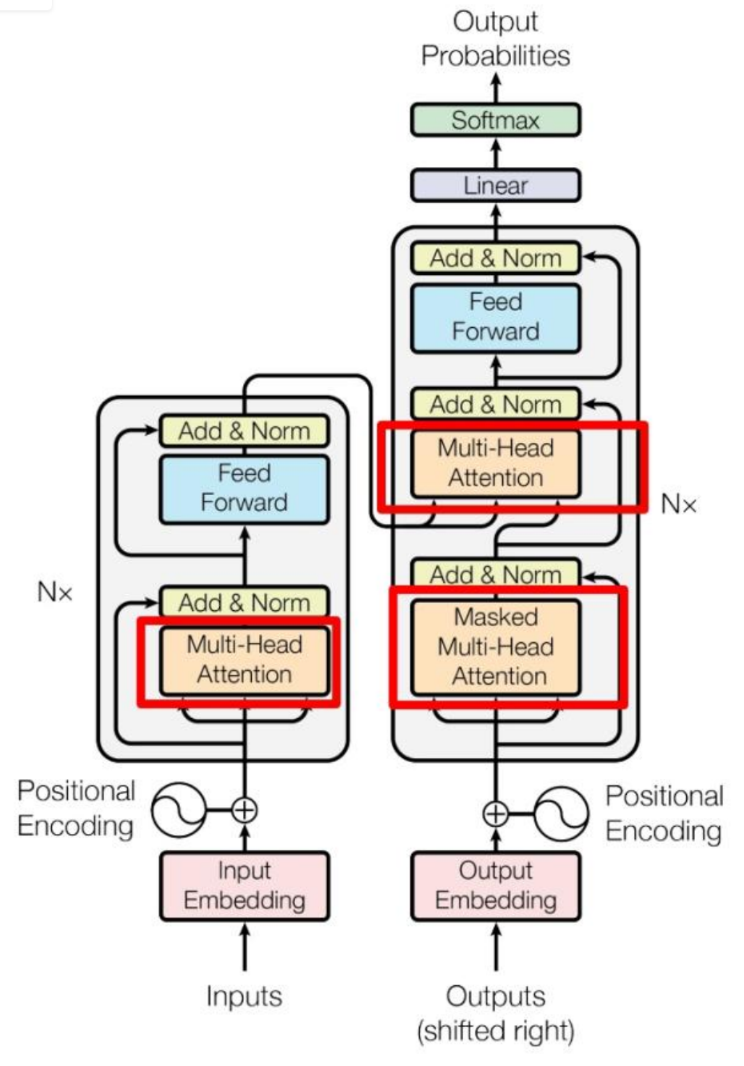

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=512, num_heads=8):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        # x.shape = (batch_size,seq_len,d_model)
        batch_size = q.shape[0]

        Q = self.W_Q(q)
        K = self.W_K(k)
        V = self.W_V(v)

        Q = Q.view(batch_size, -1, self.num_heads, self.d_k)
        K = K.view(batch_size, -1, self.num_heads, self.d_k)
        V = V.view(batch_size, -1, self.num_heads, self.d_k)
        # Q.shape = (batch_size,seq_len,num_heads,d_k)

        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)
        # Q.shape = (batch_size,num_heads,seq_len,d_k)

        K_transposed = K.transpose(-2, -1)

        scores = torch.matmul(Q, K_transposed) / math.sqrt(self.d_k)
        if mask is not None:
            # .masked_fill会替换条件为True的位置
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = F.softmax(scores, dim=-1)
        context = torch.matmul(attn_weights, V)

        context = context.transpose(1, 2).contiguous()
        context = context.view(batch_size,-1,self.d_model)

        return self.W_O(context)
    


### FeedForward

In [20]:
class FeedForward(nn.Module):
    def __init__(self, d_model=512, d_ff=2048):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(self.relu(self.linear1(x)))
    


### 单个Encoder块

In [21]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model=512, d_ff=2048, num_heads=8):
        super().__init__()
        self.multiheadattn = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff)

        self.layer_norm1 = nn.LayerNorm(d_model)
        self.layer_norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_output = self.multiheadattn(x, x, x)
        x = self.layer_norm1(x + attn_output)
        ffn_output = self.ffn(x)
        x = self.layer_norm2(ffn_output + x)
        return x




### PositionalEncoder

In [22]:
class PositionalEncoder(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        dev_term = torch.exp(torch.arange(0, d_model, 2).float() / d_model * -math.log(10000.0))

        pe[:, 0::2] = torch.sin(position * dev_term)
        pe[:, 1::2] = torch.cos(position * dev_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    
    def forward(self, x):
        return x + self.pe[: , x.shape[1],:]


### 整个Encoder模块

In [23]:
class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=512, d_ff=2048, num_heads=8, num_layers=6):
        super().__init__()
        self.vocab_size = vocab_size
        self.input_emb_layer = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoder(d_model)
        self.encoder_block = nn.ModuleList([
            EncoderBlock(d_model, d_ff, num_heads) for _ in range(num_layers)
        ])

    def forward(self, x):
        embed = self.input_emb_layer(x) # [b,s,d]
        embed = self.pos_encoder(embed)
        for layer in self.encoder_block:
            embed = layer(embed)

        return embed
        

encoder = TransformerEncoder(vocab_size=100)

BATCH_SIZE = 2
SEQ_LEN = 4

dummy_input = torch.randint(0, 100, (BATCH_SIZE, SEQ_LEN))

final_encoder_output = encoder(dummy_input)

print("经过 6 层堆叠的 Encoder 最终输出形状:", final_encoder_output.shape)
# 预期输出: torch.Size([2, 4, 512])

经过 6 层堆叠的 Encoder 最终输出形状: torch.Size([2, 4, 512])


# Decoder
### 单个Decoder块

In [24]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model=512, d_ff=2048, num_heads=8):
        super().__init__()

        self.masked_attn = MultiHeadAttention(d_model, num_heads)
        self.layer_norm1 = nn.LayerNorm(d_model)

        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.layer_norm2 = nn.LayerNorm(d_model)

        self.ffn = FeedForward(d_model, d_ff)
        self.layer_norm3 = nn.LayerNorm(d_model)

    def forward(self, x, encoder_input, tgt_mask):
        attn_score = self.masked_attn(x, x, x, tgt_mask)
        x = self.layer_norm1(x + attn_score)
        cross_attn_score = self.cross_attn(x, encoder_input, encoder_input)
        x = self.layer_norm2(x + cross_attn_score)
        ffn_output = self.ffn(x)
        x = self.layer_norm3(x + ffn_output)
        return x


### 整个Decoder模块

In [25]:
class TransformerDecoder(nn.Module):
    def __init__(self, tgt_vocab_size, d_model=512, d_ff=2048, num_heads=8, num_layers=6):
        super().__init__()
        self.input_emb_layer = nn.Embedding(tgt_vocab_size, d_model)
        self.pos_encoder = PositionalEncoder(d_model)
        self.decoder_block = nn.ModuleList([
            DecoderBlock(d_model,d_ff,num_heads) for _ in range(num_layers)
        ])

    def forward(self, x, encoder_input, mask):
        x = self.input_emb_layer(x)
        x = self.pos_encoder(x)

        for layer in self.decoder_block:
            x = layer(x, encoder_input, mask)

        return x

### 组装Transformer

In [26]:
class Transformer(nn.Module):
    def __init__(self, vocab_size, tgt_vocab_size, d_model=512, d_ff=2048, num_heads=8, num_layers=6):
        super().__init__()
        self.encoder = TransformerEncoder(
            vocab_size = vocab_size,
            d_model = d_model,
            d_ff = d_ff,
            num_heads = num_heads,
            num_layers = num_layers
        )

        self.decoder = TransformerDecoder(
            tgt_vocab_size = tgt_vocab_size,
            d_model = d_model,
            d_ff = d_ff,
            num_heads = num_heads,
            num_layers = num_layers
        )

        self.generator = nn.Linear(d_model, tgt_vocab_size)

    def forward(self, src, tgt, mask):
        encoder_output = self.encoder(src)
        decoder_output = self.decoder(tgt, encoder_output, mask)
        return self.generator(decoder_output)

### dummy data测试

In [27]:
batch_size = 2
src_seq_len = 5
tgt_seq_len = 4
src_vocab_size = 500
tgt_vocab_size = 800
d_model = 512
d_ff = 2048
num_heads = 8
num_layers = 6

src = torch.randint(0, src_vocab_size, (batch_size, src_seq_len))
tgt = torch.randint(0, tgt_vocab_size, (batch_size, tgt_seq_len))
tgt_mask = torch.tril(torch.ones(tgt_seq_len, tgt_seq_len)).unsqueeze(0).unsqueeze(0)   # [1, 1, 4, 4]


model = Transformer(
    vocab_size = src_vocab_size,
    tgt_vocab_size = tgt_vocab_size,
    d_model = d_model,
    d_ff = d_ff,
    num_heads = num_heads,
    num_layers = num_layers
)

output = model(src, tgt, tgt_mask)

print("源语言输入形状:", src.shape)     # [2, 5]
print("目标语言输入形状:", tgt.shape)   # [2, 4]
print("终极模型输出形状:", output.shape) # [2, 4, 800]



源语言输入形状: torch.Size([2, 5])
目标语言输入形状: torch.Size([2, 4])
终极模型输出形状: torch.Size([2, 4, 800])


### 循环推理

In [28]:
import torch

SOS_TOKEN = 0
EOS_TOKEN = 1
MAX_LEN = 20

src_data = torch.tensor([[12, 45, 8]])

model.eval()

def generate_translation(model, src, max_len):
    with torch.no_grad():

        encoder_output = model.encoder(src)

        trg_indexes = [SOS_TOKEN]

        for i in range(max_len):
            trg_tensor = torch.tensor([trg_indexes])

            seq_len = trg_tensor.size(1)
            trg_mask = torch.tril(torch.ones(seq_len,seq_len)).unsqueeze(0).unsqueeze(0)

            decoder_output = model.decoder(trg_tensor, encoder_output, trg_mask)
            logits = model.generator(decoder_output)

            next_word_logits = logits[:, -1, :]

            next_word_id = next_word_logits.argmax(dim=-1).item()

            trg_indexes.append(next_word_id)
            if next_word_id == EOS_TOKEN:
                print("输出结束")
                break

            

        return trg_indexes[1:]
    
generated_ids = generate_translation(model, src_data, max_len=10)

print("最终生成的词 ID 序列:", generated_ids)

最终生成的词 ID 序列: [276, 785, 612, 566, 269, 276, 230, 173, 133, 735]


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

# --- 设定特殊的 Token ID ---
PAD_ID = 0
SOS_ID = 1
EOS_ID = 2

class TranslationDataset(Dataset):
    def __init__(self, src_data, trg_data):
        """
        src_data: 源语言数据的列表，例如 [[15, 26, 8], [99, 12], ...]
        trg_data: 目标语言数据的列表，例如 [[5, 88, 2], [77, 44, 19, 8], ...]
        """
        self.src_data = src_data
        self.trg_data = trg_data
        
    def __len__(self):
        return len(self.src_data)
    
    def __getitem__(self, idx):
        # 1. 拿出原始的 ID 列表
        src_seq = self.src_data[idx]
        trg_seq = self.trg_data[idx]
        
        # 2. 给目标语言强制加上 [SOS] 和 [EOS]
        # 源语言通常不需要加 SOS，看具体的模型习惯，这里我们只给源语言加 EOS 作为结束标志
        src_seq = src_seq + [EOS_ID]
        trg_seq = [SOS_ID] + trg_seq + [EOS_ID]
        
        # 返回张量
        return torch.tensor(src_seq, dtype=torch.long), torch.tensor(trg_seq, dtype=torch.long)
    
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    """
    batch: 一个列表，里面装了 batch_size 个 Dataset 的 __getitem__ 返回值
           长这样: [(src_tensor1, trg_tensor1), (src_tensor2, trg_tensor2), ...]
    """
    src_batch = []
    trg_batch = []
    
    # 将 src 和 trg 分别收集起来
    for src_item, trg_item in batch:
        src_batch.append(src_item)
        trg_batch.append(trg_item)
        
    # pad_sequence可以自动找出列表里的最大长度，并用 padding_value 填平
    # batch_first=True 保证输出的形状是 [batch_size, seq_len] 而不是 [seq_len, batch_size]
    
    src_padded = pad_sequence(src_batch, padding_value=PAD_ID, batch_first=True)
    trg_padded = pad_sequence(trg_batch, padding_value=PAD_ID, batch_first=True)
    
    # 包装成字典返回，完美对接我们上一节的训练循环： batch['src'] 和 batch['trg']
    return {
        'src': src_padded,
        'trg': trg_padded
    }

In [ ]:
# --- 1. 制造一些长短不一的伪数据 ---
# 3 句假英文 (长度分别是 2, 4, 3)
mock_src = [
    [10, 11], 
    [20, 21, 22, 23], 
    [30, 31, 32]
]
# 3 句对应的假中文 (长度分别是 3, 2, 5)
mock_trg = [
    [100, 101, 102], 
    [200, 201], 
    [300, 301, 302, 303, 304]
]

# --- 2. 实例化 Dataset ---
dataset = TranslationDataset(mock_src, mock_trg)

# --- 3. 实例化 DataLoader ---
# 把 collate_fn 传进去
dataloader = DataLoader(
    dataset, 
    batch_size=2,      # 我们一次拿 2 句话出来
    shuffle=True,      # 打乱顺序，让模型泛化能力更强
    collate_fn=collate_fn # 整理函数
)

# --- 4. 输出 ---
for batch_idx, batch in enumerate(dataloader):
    print(f"=== Batch {batch_idx + 1} ===")
    print("源语言矩阵形状:", batch['src'].shape)
    print("源语言矩阵内容:\n", batch['src'])
    print("目标语言矩阵形状:", batch['trg'].shape)
    print("目标语言矩阵内容:\n", batch['trg'])
    print("-" * 30)

=== Batch 1 ===
源语言矩阵形状: torch.Size([2, 4])
源语言矩阵内容:
 tensor([[10, 11,  2,  0],
        [30, 31, 32,  2]])
目标语言矩阵形状: torch.Size([2, 7])
目标语言矩阵内容:
 tensor([[  1, 100, 101, 102,   2,   0,   0],
        [  1, 300, 301, 302, 303, 304,   2]])
------------------------------
=== Batch 2 ===
源语言矩阵形状: torch.Size([1, 5])
源语言矩阵内容:
 tensor([[20, 21, 22, 23,  2]])
目标语言矩阵形状: torch.Size([1, 4])
目标语言矩阵内容:
 tensor([[  1, 200, 201,   2]])
------------------------------


In [34]:
import torch.optim as optim
# --- 1. 前置准备 ---
# model: 我们之前手撕的 Transformer(src_vocab, trg_vocab)
# dataloader: PyTorch 的 DataLoader，负责源源不断吐出 batch 数据
# PAD_TOKEN: 填充符的 ID，假设为 0

PAD_TOKEN = 0
EPOCHS = 10
LEARNING_RATE = 0.0001

src_data = [[15, 26, 8], [99, 12]]
trg_data = [[5, 88, 2], [77, 44, 19, 8]]

# 定义优化器
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 定义损失函数，极其关键：忽略 PAD_TOKEN 的 Loss！
criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)

# 将模型放到 GPU 上 (如果有的话)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# --- 2. 开始宏大的训练循环 ---
for epoch in range(EPOCHS):
    model.train() # 开启训练模式 (启用 Dropout 等)
    total_epoch_loss = 0
    
    for batch_idx, batch in enumerate(dataloader):
        # 从 batch 中拿出源语言和目标语言的 ID 矩阵
        # src 形状: [batch_size, src_len]
        # trg 形状: [batch_size, trg_len]
        src = batch['src'].to(device)
        trg = batch['trg'].to(device)
        
        # ==========================================
        # 核心动作一：错位切分 (Teacher Forcing)
        # ==========================================
        # Decoder 的输入：砍掉最后一个词
        trg_input = trg[:, :-1] 
        # 算 Loss 的目标：砍掉第一个词 [SOS]
        trg_target = trg[:, 1:] 
        
        # 动态生成下三角掩码 (针对此时的 trg_input 长度)
        seq_len = trg_input.size(1)
        trg_mask = torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0).unsqueeze(0).to(device)
        
        # ==========================================
        # 核心动作二：清空旧梯度，前向传播
        # ==========================================
        optimizer.zero_grad()
        
        # logits 形状: [batch_size, trg_len - 1, trg_vocab_size]
        logits = model(src, trg_input, trg_mask)
        
        # ==========================================
        # 核心动作三：维度变形与计算 Loss
        # ==========================================
        # 将三维 logits 拍扁成二维: [batch_size * (trg_len - 1), trg_vocab_size]
        # contiguous() 是为了防止底层内存不连续报错
        flat_logits = logits.contiguous().view(-1, logits.shape[-1])
        
        # 将二维 target 拍扁成一维: [batch_size * (trg_len - 1)]
        flat_target = trg_target.contiguous().view(-1)
        
        # 裁判打分！
        loss = criterion(flat_logits, flat_target)
        
        # ==========================================
        # 核心动作四：反向传播与参数更新
        # ==========================================
        loss.backward()
        
        # 工业界防爆小技巧：梯度裁剪 (防止梯度爆炸)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_epoch_loss += loss.item()
        
        # 打印日志
        if batch_idx % 100 == 0:
            print(f"Epoch: {epoch+1}/{EPOCHS} | Batch: {batch_idx} | Loss: {loss.item():.4f}")
            
    # 计算整个 Epoch 的平均 Loss
    avg_loss = total_epoch_loss / len(dataloader)
    print(f"=== Epoch {epoch+1} Completed | Average Loss: {avg_loss:.4f} ===")

Epoch: 1/10 | Batch: 0 | Loss: 7.0315
=== Epoch 1 Completed | Average Loss: 6.7589 ===
Epoch: 2/10 | Batch: 0 | Loss: 3.1020
=== Epoch 2 Completed | Average Loss: 3.4342 ===
Epoch: 3/10 | Batch: 0 | Loss: 2.5677
=== Epoch 3 Completed | Average Loss: 2.7360 ===
Epoch: 4/10 | Batch: 0 | Loss: 1.6875
=== Epoch 4 Completed | Average Loss: 1.2726 ===
Epoch: 5/10 | Batch: 0 | Loss: 0.8484
=== Epoch 5 Completed | Average Loss: 0.5689 ===
Epoch: 6/10 | Batch: 0 | Loss: 0.3529
=== Epoch 6 Completed | Average Loss: 0.2181 ===
Epoch: 7/10 | Batch: 0 | Loss: 0.0939
=== Epoch 7 Completed | Average Loss: 0.1181 ===
Epoch: 8/10 | Batch: 0 | Loss: 0.0614
=== Epoch 8 Completed | Average Loss: 0.0411 ===
Epoch: 9/10 | Batch: 0 | Loss: 0.0237
=== Epoch 9 Completed | Average Loss: 0.0302 ===
Epoch: 10/10 | Batch: 0 | Loss: 0.0249
=== Epoch 10 Completed | Average Loss: 0.0205 ===
